In [116]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#MODEELLING
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score 
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression,Lasso,Ridge
from sklearn.model_selection import RandomizedSearchCV,train_test_split
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
#ENCODING
# from sklearn.preprocessing import OneHotEncoder, StandardScaler
# from sklearn.compose import ColumnTransformer



import warnings
warnings.filterwarnings("ignore")

In [117]:
df = pd.read_csv("data/stud.csv")
df.head(2)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88


In [118]:
x = df.drop(columns=['math_score'])
x.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [119]:
y=df['math_score']
y.head()

0    72
1    69
2    90
3    47
4    76
Name: math_score, dtype: int64

In [120]:
#create column transformer with 3 types of transformers
num_features = x.select_dtypes(include="number").columns
cat_featurees = x.select_dtypes(include=["object","str"]).columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

num_transformer = StandardScaler()
cat_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder",cat_transformer,cat_featurees),
        ("StandardScaler",num_transformer,num_features)
    ]
)


In [121]:
x = preprocessor.fit_transform(x)


In [122]:
x

array([[ 1.        ,  0.        ,  0.        , ...,  1.        ,
         0.19399858,  0.39149181],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         1.42747598,  1.31326868],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.77010859,  1.64247471],
       ...,
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.12547206, -0.20107904],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.60515772,  0.58901542],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.15336989,  1.18158627]], shape=(1000, 19))

In [123]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2) #,random_state=43
y

0      72
1      69
2      90
3      47
4      76
       ..
995    88
996    62
997    59
998    68
999    77
Name: math_score, Length: 1000, dtype: int64

In [124]:
def evaluatemodel(true,pred):
    mae = mean_absolute_error(true,pred)
    mse = mean_squared_error(true,pred)
    rmse = np.sqrt(mean_squared_error(true,pred))
    r2  = r2_score(true,pred)

    return mae,mse,rmse,r2 

In [125]:
models={
    "LinearRegression" : LinearRegression(),
    "Lasso" : Lasso(),
    "Ridge" : Ridge(),
    "KNeighborsRegressor" : KNeighborsRegressor(),
    "DecisionTreeRegressor" : DecisionTreeRegressor(),
    "RandomForestRegressor" : RandomForestRegressor(),
    "XGBRegressor" : XGBRegressor(),
    "CatBoostRegressor" : CatBoostRegressor(),
    "AdaBoostRegressor" : AdaBoostRegressor()
}

model_list = []
r2_list = []


for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(x_train,y_train)  #TRAIN

    #MAKE PREDICTION
    y_train_pred = model.predict(x_train) 
    y_test_pred = model.predict(x_test) 

    #EVALUATE
    trainmae, trainmse , trainrmse , trainr2 = evaluatemodel(y_train,y_train_pred)
    testmae, testmse , testsmse , testr2 =evaluatemodel(y_test,y_test_pred)

    print(list(models.keys())[i])
    print("-"*30)
    print("TRAINING SET ")
    print("MAE :{:.4f}".format(trainmae))
    print("MSE :{:.4f}".format(trainmse))
    print("RMSE:{:.4f}".format(trainrmse))
    print("R2  :{:.4f}".format(trainr2))
    print("="*30)
    print("TEST SET ")
    print("MAE :{:.4f}".format(testmae))
    print("MSE :{:.4f}".format(testmse))
    print("RMSE:{:.4f}".format(testsmse))
    print("R2  :{:.4f}".format(testr2))
    model_list.append(list(models.keys())[i])
    r2_list.append(testr2)
    print("="*30,"\n\n")


LinearRegression
------------------------------
TRAINING SET 
MAE :4.3139
MSE :29.0631
RMSE:5.3910
R2  :0.8743
TEST SET 
MAE :4.0027
MSE :25.6449
RMSE:5.0641
R2  :0.8839


Lasso
------------------------------
TRAINING SET 
MAE :5.2193
MSE :43.5546
RMSE:6.5996
R2  :0.8117
TEST SET 
MAE :4.8065
MSE :37.7919
RMSE:6.1475
R2  :0.8289


Ridge
------------------------------
TRAINING SET 
MAE :4.3139
MSE :29.0655
RMSE:5.3912
R2  :0.8743
TEST SET 
MAE :4.0017
MSE :25.6622
RMSE:5.0658
R2  :0.8838


KNeighborsRegressor
------------------------------
TRAINING SET 
MAE :4.7153
MSE :34.9718
RMSE:5.9137
R2  :0.8488
TEST SET 
MAE :5.3140
MSE :48.0136
RMSE:6.9292
R2  :0.7826


DecisionTreeRegressor
------------------------------
TRAINING SET 
MAE :0.0238
MSE :0.1381
RMSE:0.3717
R2  :0.9994
TEST SET 
MAE :6.1750
MSE :64.1450
RMSE:8.0091
R2  :0.7096


RandomForestRegressor
------------------------------
TRAINING SET 
MAE :1.8397
MSE :5.3830
RMSE:2.3201
R2  :0.9767
TEST SET 
MAE :4.5320
MSE :34.2222
RMSE:

In [126]:
pd.DataFrame(list(zip(model_list,r2_list)), columns=["MODELS","R2_SCORE"]).sort_values(by="R2_SCORE",ascending=False)

,MODELS,R2_SCORE
0,LinearRegression,0.883886
2,Ridge,0.883808
7,CatBoostRegressor,0.860202
8,AdaBoostRegressor,0.854707
5,RandomForestRegressor,0.845050
1,Lasso,0.828887
6,XGBRegressor,0.827604
3,KNeighborsRegressor,0.782606
4,DecisionTreeRegressor,0.709567


Text(0, 0.5, 'Predicted')

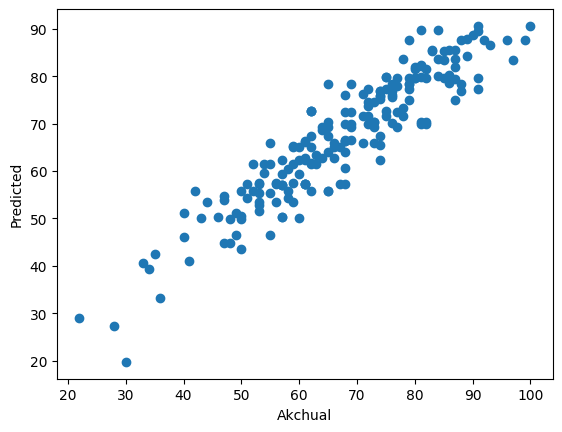

In [129]:
plt.scatter(y_test,y_test_pred)
plt.xlabel("Akchual")
plt.ylabel("Predicted")

<Axes: xlabel='math_score'>

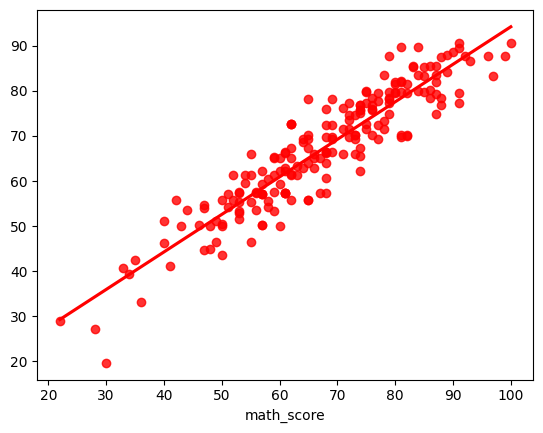

In [133]:
sns.regplot(x=y_test,y=y_test_pred,ci=None,color="red")

In [137]:
pred_df=pd.DataFrame({"Actual_Values":y_test,"Predicted_Values":y_test_pred,"Difference":y_test-y_test_pred})
pred_df

,Actual_Values,Predicted_Values,Difference
530,68,63.962343,4.037657
32,56,57.473282,-1.473282
710,93,86.596774,6.403226
261,79,78.388430,0.611570
355,61,62.787879,-1.787879
...,...,...,...
770,52,55.761780,-3.761780
596,30,19.710526,10.289474
313,68,57.286624,10.713376
148,68,69.858896,-1.858896


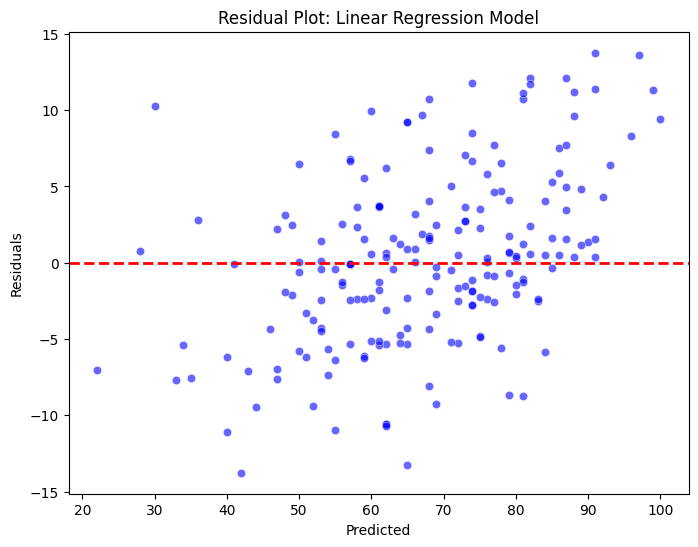

In [138]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=pred_df["Actual_Values"], y= pred_df["Difference"], alpha=0.6,color="blue")
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)

plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot: Linear Regression Model")

plt.show()